<a href="https://colab.research.google.com/github/ole0246/LanguageModelsAsCognitiveModels/blob/main/DSC_291_HW1_Evaluating_BabyLMs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Section 1: Instructions, Setup, and Introduction to Minicons

In this homework, you will gain practice evaluating LMs using minimal pairs, and also make your own mini-research contributions.

1. **Section 1 (0 points):** Setup and intro to the minicons library for scoring sentence surprisal
2. **Section 2 (3 points):** BLiMP evaluation
3. **Section 3 (4 points):** Write your own minimal pairs datasets
4. **Section 4 (5 points):** Mini-project
5. **Section 5 (0 points):** Submit

Note: We've decided to split HW1 up into two parts. Part 1 is worth 12 points. Part 2 will be released later and is worth 13 points.

**GENERATIVE AI POLICY:**
For this homework, the use of LLMs is allowed for brainstorming and code generation BUT you need to do two things:

- You must disclose all generative AI use.
- You must describe all generative AI contributions *in your own words*.

## Instructions, Setup, and Introduction to Minicons (0 Points)

- Step 1: Make a copy of this notebook.
- Step 2: Connect to GPU (if needed).
   - We recommend connecting to T4 GPUs for compute-intensive tasks, like evaluating models on lots of minimal pairs. To do so, go to `Runtime > Change runtime type > Hardware accelerator` and select `T4 GPU`. There are usage limits (for free accounts), so you may want to connect to GPU only when needed. This notebook can also be run on university clusters where free GPUs are provided (let us know if you need support with this).
- Step 3: Run the setup cells.
- Step 4: Complete the assignment.
- Step 5: Convert the notebook to .pdf (see instructions at the bottom).
- Step 6: Submit using Gradescope (link on the course canvas site).

In [4]:
# Install required packages
!pip install git+https://github.com/kanishkamisra/minicons.git
!pip install datasets
!pip install "transformers<4.50" -q

  Cloning https://github.com/kanishkamisra/minicons.git to /tmp/pip-req-build-ctzt6vqd
  Running command git clone --filter=blob:none --quiet https://github.com/kanishkamisra/minicons.git /tmp/pip-req-build-ctzt6vqd
  Resolved https://github.com/kanishkamisra/minicons.git to commit b946cd42bef4b619a316a4551d31911d6da5cbb9
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.7/51.7 kB 2.6 MB/s eta 0:00:00
  Created wheel for minicons: filename=minicons-0.3.36-py3-none-any.whl size=41733 sha256=169b052619010f9d301845c1c70ff984213b8676c2b086099f486bd3d9e30550
  Stored in directory: /tmp/pip-ephem-wheel-cache-av0wn73q/wheels/cc/f0/47/f6726e6460e28ecec2a74f998043ddee1beb40d17d0e42138b
Successfully built minicons
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 94.7 MB/s eta 0:0

In [5]:
from minicons import scorer
import torch
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
from datasets import load_dataset

## Minicons

[Minicons](https://github.com/kanishkamisra/minicons) is a Python library that provides a simple interface for computing token-level and sentence-level surprisal scores from pretrained language models. It supports both **decoder-only** (causal/incremental) models like GPT-2 and **encoder-only** (masked) models like BERT.

**What does Minicons do?**

- Computes **surprisal** (negative log-probability) at the token and sequence level.
- Supports multiple scoring strategies: raw log-probability, normalized surprisal, etc.
- Works with any HuggingFace model out of the box. *NOTE: Currently, support for MLMs only seems to be compatible with Transformers versions 4.50 or earlier.*

**Why is this useful?**

Surprisal-based evaluation allows us to do **zero-shot grammaticality judgments** — we can compare the surprisal of a grammatical sentence to an ungrammatical one without any task-specific fine-tuning. A well-trained language model should assign **lower surprisal** (higher probability) to the grammatical sentence.

**Scorer types:**

- `scorer.IncrementalLMScorer` — for decoder-only / causal LMs (e.g., GPT-2, DistilGPT-2)
- `scorer.MaskedLMScorer` — for encoder-only / masked LMs (e.g., BERT)

**Reduction functions for `sequence_score`:**

- Sequence Surprisal: `lambda x: -x.sum(0).item()`
- Normalized Surprisal: `lambda x: -x.mean(0).item()`
- Sequence Log-probability: `lambda x: x.sum(0).item()`
- Normalized Log-probability: `lambda x: x.mean(0).item()`

Now we can use Minicons with Decoder-Only and Encoder-Only Models

Below we demonstrate how to use `minicons` with both types of models on example minimal pairs. **Minimal pairs** are pairs of sentences that differ in exactly one grammatical feature, allowing us to isolate what a model knows about that specific phenomenon.

In [6]:
if torch.cuda.is_available():
    device = 'cuda'
else:
    device = 'cpu'

# Load models
ilm_model = scorer.IncrementalLMScorer('gpt2-large', device) # Autoregressive (Decoder) LM
mlm_model = scorer.MaskedLMScorer('bert-base-uncased', device)  # Bidirectional (Masked) LM

# Example minimal pairs
stimuli = [
    ["The keys to the cabinet are on the table.", "The keys to the cabinet is on the table."],
    ["Buddy is easy to sleep.", "Buddy is eager to sleep."],
    ["It's herself that Sharon talked about.", "It's herself that talked about Sharon."],
    ["There seems to be a dog under the table.", "There tried to be a dog under the table."],
    ["Buddy dropped the bone.", "Buddy fell the bone."],
    ["I know that you saw the dog.", "I know who you saw the dog."],
]

# Score and display
for i, stim in tqdm(enumerate(stimuli, 1)):
    print(f"--- Stimulus {i} ---")
    print(f"Sentences: {stim}")
    scores_ilm = ilm_model.sequence_score(stim, reduction=lambda x: -x.sum(0).item())
    scores_mlm = mlm_model.sequence_score(stim, reduction=lambda x: -x.sum(0).item())

    print(f"GPT2-large (autoregressive) surprisal: {scores_ilm}")
    print(f"BERT (bidirectional) surprisal: {scores_mlm}")
    print()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/666 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

0it [00:00, ?it/s]

--- Stimulus 1 ---
Sentences: ['The keys to the cabinet are on the table.', 'The keys to the cabinet is on the table.']
GPT2-large (autoregressive) surprisal: [30.28804588317871, 34.02823257446289]
BERT (bidirectional) surprisal: [13.962696075439453, 23.415111541748047]

--- Stimulus 2 ---
Sentences: ['Buddy is easy to sleep.', 'Buddy is eager to sleep.']
GPT2-large (autoregressive) surprisal: [32.170745849609375, 30.552865982055664]
BERT (bidirectional) surprisal: [33.147586822509766, 24.857433319091797]

--- Stimulus 3 ---
Sentences: ["It's herself that Sharon talked about.", "It's herself that talked about Sharon."]
GPT2-large (autoregressive) surprisal: [39.759376525878906, 43.571041107177734]
BERT (bidirectional) surprisal: [24.77452850341797, 29.058025360107422]

--- Stimulus 4 ---
Sentences: ['There seems to be a dog under the table.', 'There tried to be a dog under the table.']
GPT2-large (autoregressive) surprisal: [31.762176513671875, 39.669376373291016]
BERT (bidirectional) 

# Section 2: BLiMP Evaluation (3 points)

[BLiMP](https://github.com/alexwarstadt/blimp) (Benchmark of Linguistic Minimal Pairs) consists of 67 sub-datasets, each containing 1,000 minimal pairs that isolate specific contrasts in syntax, morphology, or semantics.

**Task:**

1. Pick **three phenomena** (sub-tasks) from BLiMP that interest you. Try to pick tasks that **vary in difficulty**.
2. Write a **function** to evaluate a model on BLiMP.
3. Evaluate Pythia checkpoints on BLiMP sub-tasks.
  - Tip: You can limit evaluation to 100 minimal pairs per sub-task, rather than 1000.
4. **Plot** the results as a line plots comparing the change in performance throughout training.
5. **Explain** your results: Which model performs better? Why might that be?

## Select BLiMP Phenomena

You can browse the available sub-tasks and model performance in Table 4 [here](https://arxiv.org/pdf/1912.00582). Make sure to pick sub-tasks of different difficulty. Some examples:

- Easy
    - `anaphor_gender_agreement`
    - `existential_there_subject_raising`
    - `determiner_noun_agreement_with_adj_2`
    - `irregular_past_participle_adjectives`
- Medium
    - `causative`
    - `ellipsis_n_bar_2`
    - `wh_island`
    - `superlative_quantifiers_1`
- Hard
    - `principle_A_c_command`
    - `wh_vs_that_with_gap`
    - `matrix_question_npi_licensor_present`
    - `distractor_agreement_relative_clause`

In [7]:
# Run this block to list all BLiMP subtasks by their official task_names
from datasets import get_dataset_config_names

# Get all sub-task names (configurations) for BLiMP
blimp_tasks = get_dataset_config_names("nyu-mll/blimp")

print(f"Total BLiMP sub-tasks: {len(blimp_tasks)}")
print("\n".join(blimp_tasks))

README.md: 0.00B [00:00, ?B/s]

Total BLiMP sub-tasks: 67
adjunct_island
anaphor_gender_agreement
anaphor_number_agreement
animate_subject_passive
animate_subject_trans
causative
complex_NP_island
coordinate_structure_constraint_complex_left_branch
coordinate_structure_constraint_object_extraction
determiner_noun_agreement_1
determiner_noun_agreement_2
determiner_noun_agreement_irregular_1
determiner_noun_agreement_irregular_2
determiner_noun_agreement_with_adj_2
determiner_noun_agreement_with_adj_irregular_1
determiner_noun_agreement_with_adj_irregular_2
determiner_noun_agreement_with_adjective_1
distractor_agreement_relational_noun
distractor_agreement_relative_clause
drop_argument
ellipsis_n_bar_1
ellipsis_n_bar_2
existential_there_object_raising
existential_there_quantifiers_1
existential_there_quantifiers_2
existential_there_subject_raising
expletive_it_object_raising
inchoative
intransitive
irregular_past_participle_adjectives
irregular_past_participle_verbs
irregular_plural_subject_verb_agreement_1
irregular_p

Your BLiMP Sub-Tasks

1. \<anaphor_gender_agreement\>
2. \<superlative_quantifiers_1\>
3. \<distractor_agreement_relative_clause\>

## Complete the evaluation function

In [8]:
# Complete this evaluation function. Add any helper functions you need.

def evaluate(task_name, ms_scorer, normalize=False, n=100):
    """Evaluate a model on a BLiMP sub-task.
       - task_name: a BLiMP task name
       - ms_scorer: a minicons scorer
       - normalize: whether or not to normalize surprisal by number of tokens
       - n: number of minimal pairs to evaluate on
       - Returns: Accuracy (0 to 1)."""
    ds = load_dataset("nyu-mll/blimp", task_name)

    reduction = (lambda x: -x.mean(0).item()) if normalize else (lambda x: -x.sum(0).item())

    # Use select to get a subset as a dataset object which preserves the dictionary structure per row
    subset = ds['train'].select(range(min(len(ds['train']), n)))

    correct = 0
    total = 0

    for ex in tqdm(subset, desc=f"Evaluating on {task_name}", leave=False):

      # surprisal for both sentences (lower = better / more probable)
      s_good, s_bad = ms_scorer.sequence_score([ex["sentence_good"], ex["sentence_bad"]], reduction=reduction)

      if s_good < s_bad:
          correct += 1
      total += 1

    accuracy = correct / total if total > 0 else float("nan")

    return accuracy




## Evaluate Pythia Checkpoints

[Pythia](https://huggingface.co/EleutherAI/pythia-160m-deduped-v0) is a family of open-source and open-weight LLMs trained by the non-profit Eleuther AI.

To aid interpretability research, Eleuther released checkpoints throughout training for all the Pythia models, meaning we can track how model performance changes throughout pretraining.

You will evaluate 4 checkpoints at roughly log-linear intervals.



In [9]:
from transformers import GPTNeoXForCausalLM, AutoTokenizer

def load_pythia(ckpt):
    model = GPTNeoXForCausalLM.from_pretrained(
    "EleutherAI/pythia-70m-deduped",
    revision=f"step{ckpt}",
    cache_dir=f"./pythia-70m-deduped/step{ckpt}",
    )

    tokenizer = AutoTokenizer.from_pretrained(
    "EleutherAI/pythia-70m-deduped",
    revision=f"step{ckpt}",
    cache_dir=f"./pythia-70m-deduped/step{ckpt}",
    )
    return model, tokenizer

steps = [128, 1000, 10000, 143000]
ckpts = {}
for step in steps:
    ckpts[step] = load_pythia(step)

config.json:   0%|          | 0.00/567 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/282M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/396 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/99.0 [00:00<?, ?B/s]

...

config.json:   0%|          | 0.00/567 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/282M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/396 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/99.0 [00:00<?, ?B/s]

In [10]:
# Evaluate your models and put the results into a pandas dataframe

tasks = [
    "anaphor_gender_agreement",
    "superlative_quantifiers_1",
    "distractor_agreement_relative_clause",
]

rows = []
n_pairs = 100
normalize = False

for ckpt in ckpts.keys():
    ms_scorer = scorer.IncrementalLMScorer(ckpts[ckpt][0], device, tokenizer=ckpts[ckpt][1])
    for task in tasks:
        acc = evaluate(task, ms_scorer, normalize=normalize, n=n_pairs)
        rows.append(
            {
                "ckpt": ckpt,
                "task": task,
                "accuracy": acc,
                "normalize": normalize,
                "n": n_pairs,
            }
        )

results_df = pd.DataFrame(rows).sort_values(["task", "ckpt"]).reset_index(drop=True)

print(results_df.head(10))
print(results_df.describe())

/usr/local/lib/python3.12/dist-packages/minicons/scorer.py:1410: UserWarning: tokenizer is changed by adding pad_token_id to the tokenizer.
  warnings.warn(


anaphor_gender_agreement/train-00000-of-(…):   0%|          | 0.00/39.2k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/1000 [00:00<?, ? examples/s]

Evaluating on anaphor_gender_agreement:   0%|          | 0/100 [00:00<?, ?it/s]

superlative_quantifiers_1/train-00000-of(…):   0%|          | 0.00/48.5k [00:00<?, ?B/s]

...

Evaluating on distractor_agreement_relative_clause:   0%|          | 0/100 [00:00<?, ?it/s]

Evaluating on anaphor_gender_agreement:   0%|          | 0/100 [00:00<?, ?it/s]

Evaluating on superlative_quantifiers_1:   0%|          | 0/100 [00:00<?, ?it/s]

Evaluating on distractor_agreement_relative_clause:   0%|          | 0/100 [00:00<?, ?it/s]

     ckpt                                  task  accuracy  normalize    n
0     128              anaphor_gender_agreement      0.30      False  100
1    1000              anaphor_gender_agreement      0.54      False  100
2   10000              anaphor_gender_agreement      0.84      False  100
3  143000              anaphor_gender_agreement      0.82      False  100
4     128  distractor_agreement_relative_clause      0.46      False  100
5    1000  distractor_agreement_relative_clause      0.34      False  100
6   10000  distractor_agreement_relative_clause      0.59      False  100
7  143000  distractor_agreement_relative_clause      0.71      False  100
8     128             superlative_quantifiers_1      0.48      False  100
9    1000             superlative_quantifiers_1      0.52      False  100
                ckpt  accuracy      n
count      12.000000  12.00000   12.0
mean    38532.000000   0.56500  100.0
std     63125.753903   0.16855    0.0
min       128.000000   0.30000  10

## Plot the results

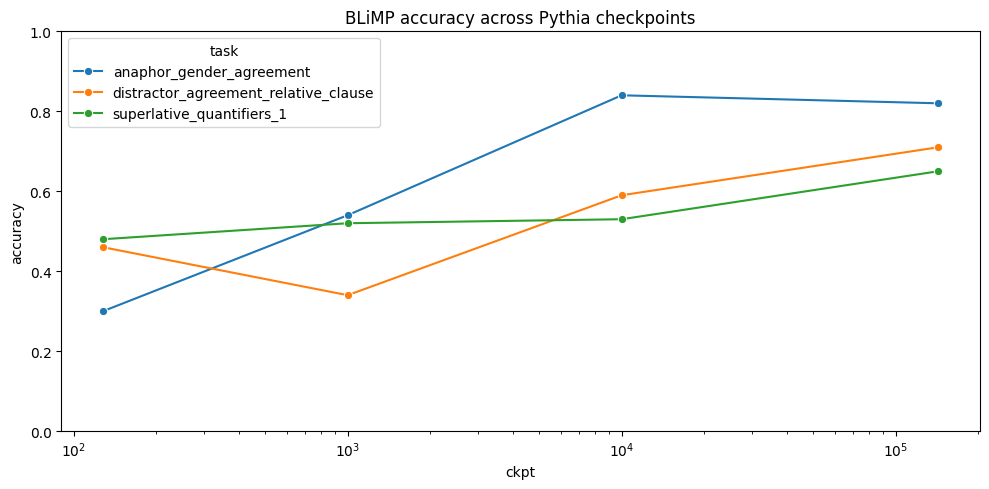

In [11]:
# Plot your results in a line plot using seaborn

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
sns.lineplot(data=results_df, x="ckpt", y="accuracy", hue="task", marker="o")
plt.xscale("log")
plt.ylim(0, 1)
plt.title("BLiMP accuracy across Pythia checkpoints")
plt.tight_layout()
plt.show()

## Generative AI Usage
Describe any contributions made by generative AI in this portion of the assignment.

*[Your answer here]*

# Section 3: Create Your Own Evaluation Pairs (4 points)

**Mini-Benchmark:** Create **at least 3** minimal pairs datasets of your own with at least 5 pairs each. For each dataset:

1. Select a phenomenon to test. In a markdown cell, explain **what phenomenon** you are testing (e.g., subject-verb agreement, reflexive binding, negative polarity items, etc.).
2. Write 5 pairs with one good sentence and its bad counterpart.
3. Score your pairs using `minicons` with the Pythia checkpoints. Plot the results as before.
4. Summarize your findings.

Some ideas for minimal pair datasets are provided in this [google doc](https://docs.google.com/document/d/1jRyKssx0haSfnh4g94YNI4C5mKvGgWzWM3af7Acz7_8/edit?tab=t.0). You are welcome to use these ideas or come up with your own.

## Describe the phenomena you are testing with each pair

### Dataset 1: Subject–verb agreement with prepositional phrase (PP)
**Phenomenon:** Subject–verb number agreement when a distracting prepositional phrase intervenes.  
These minimal pairs test whether the model correctly agrees the verb with the true head noun of the subject (e.g., *key*), rather than a nearby plural noun inside a prepositional phrase (e.g., *mysteries*).  
Example: “The key to the many mysteries **is** …” (good) vs “The key to the many mysteries **are** …” (bad).

### Dataset 2: World knowledge about materials and their properties
**Phenomenon:** Selectional plausibility and real-world expectations about material's typical properties.  
These pairs keep the sentence structure constant but swap the material (e.g., glass vs wood) so that one sentence matches everyday knowledge about what typically happens (glass shatters easily) and the other conflicts with it. The “bad” sentences are usually still grammatical, but they are implausible given commonsense knowledge.

### Dataset 3: Basic English word order (SVO)
**Phenomenon:** Canonical English constituent order: Subject–Verb–Object.  
These minimal pairs test whether the model assigns lower surprisal to grammatical SVO sentences (e.g., “Buddy chased the squirrel.”) than to scrambled orders that violate English syntax (e.g., “Buddy the squirrel chased.”). This targets a very basic syntactic generalization about word order.

## Your mini-benchmark

In [12]:
# Your minimal pairs datasets

# Dataset 1: subject–verb agreement with an attractor in a PP
dataset1 = [
    {"sentence_good": "The key to the cabinets is on the table.",
     "sentence_bad":  "The key to the cabinets are on the table."},

    {"sentence_good": "The bouquet of roses smells wonderful.",
     "sentence_bad":  "The bouquet of roses smell wonderful."},

    {"sentence_good": "The label on the bottles is torn.",
     "sentence_bad":  "The label on the bottles are torn."},

    {"sentence_good": "The author of the books is arriving soon.",
     "sentence_bad":  "The author of the books are arriving soon."},

    {"sentence_good": "The picture of the mountains was framed nicely.",
     "sentence_bad":  "The picture of the mountains were framed nicely."},
]

# Dataset 2: World knowledge about materials & properties
dataset2 = [
    {"sentence_good": "The towel is cotton, so it will absorb the water.",
     "sentence_bad":  "The towel is plastic, so it will absorb the water."},

    {"sentence_good": "The mug is ceramic, so it might break if dropped.",
     "sentence_bad":  "The mug is rubber, so it might break if dropped."},

    {"sentence_good": "The window is made of glass, so it is transparent.",
     "sentence_bad":  "The window is made of stone, so it is transparent."},

    {"sentence_good": "The raincoat is waterproof, so it will keep you dry.",
     "sentence_bad":  "The raincoat is made of paper, so it will keep you dry."},

    {"sentence_good": "The sweater is made of wool, so it will keep you warm.",
     "sentence_bad":  "The sweater is made of ice, so it will keep you warm."},
]

# Dataset 3: basic word order (SVO vs scrambled/ungrammatical order)
dataset3 = [
    {"sentence_good": "Buddy chased the dog.",
     "sentence_bad":  "Buddy the dog chased."},

    {"sentence_good": "The teacher praised the student.",
     "sentence_bad":  "The teacher the student praised."},

    {"sentence_good": "The dog frightened the cat.",
     "sentence_bad":  "The dog the cat frightened."},

    {"sentence_good": "Maria opened the door.",
     "sentence_bad":  "Maria the door opened."},

    {"sentence_good": "The chef cooked the meal.",
     "sentence_bad":  "The chef the meal cooked."},
]

## Evaluate Pythia on your mini-benchmark

      ckpt                    dataset  accuracy  n_pairs  normalize
0      128       basic_word_order_svo       1.0        5      False
1     1000       basic_word_order_svo       1.0        5      False
2    10000       basic_word_order_svo       1.0        5      False
3   143000       basic_word_order_svo       1.0        5      False
4      128  sv_agreement_pp_attractor       0.8        5      False
5     1000  sv_agreement_pp_attractor       1.0        5      False
6    10000  sv_agreement_pp_attractor       1.0        5      False
7   143000  sv_agreement_pp_attractor       0.8        5      False
8      128  world_knowledge_materials       0.6        5      False
9     1000  world_knowledge_materials       0.4        5      False
10   10000  world_knowledge_materials       0.8        5      False
11  143000  world_knowledge_materials       0.6        5      False


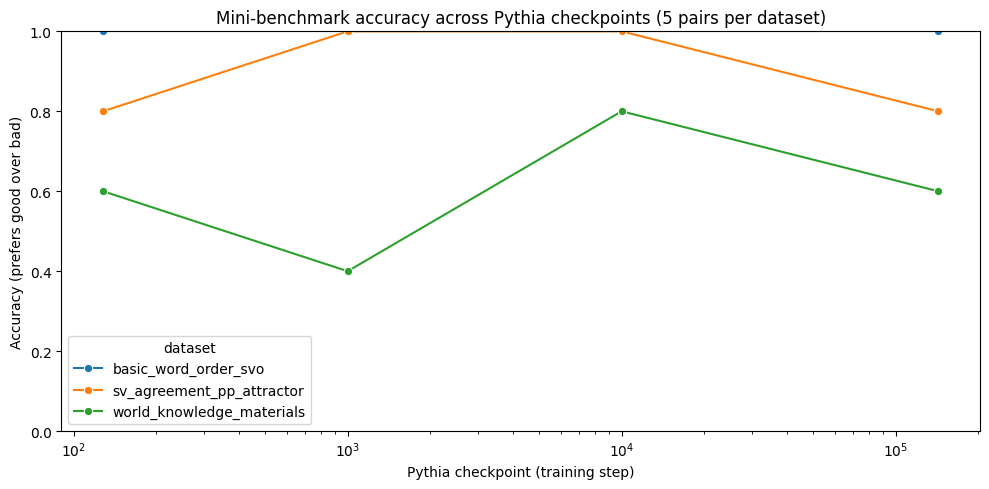

In [14]:
def evaluate_minibench(pairs, ms_scorer, normalize=False):
    """
    pairs: list[dict] with keys: sentence_good, sentence_bad
    Returns: accuracy in [0, 1] where correct means surprisal(good) < surprisal(bad).
    """
    reduction = (lambda x: -x.mean(0).item()) if normalize else (lambda x: -x.sum(0).item())

    correct = 0
    total = 0
    for ex in pairs:
        s_good, s_bad = ms_scorer.sequence_score(
            [ex["sentence_good"], ex["sentence_bad"]],
            reduction=reduction
        )
        correct += int(s_good < s_bad)
        total += 1

    return correct / total if total > 0 else float("nan")

mini_datasets = {
    "sv_agreement_pp_attractor": dataset1,
    "world_knowledge_materials": dataset2,
    "basic_word_order_svo": dataset3,
}

# Evaluate across checkpoints
rows = []
normalize = False

for ckpt in sorted(ckpts.keys()):
    ms_scorer = scorer.IncrementalLMScorer(
        ckpts[ckpt][0],
        device,
        tokenizer=ckpts[ckpt][1]
    )

    for ds_name, pairs in mini_datasets.items():
        acc = evaluate_minibench(pairs, ms_scorer, normalize=normalize)
        rows.append(
            {
                "ckpt": ckpt,
                "dataset": ds_name,
                "accuracy": acc,
                "n_pairs": len(pairs),
                "normalize": normalize,
            }
        )

mini_results_df = pd.DataFrame(rows).sort_values(["dataset", "ckpt"]).reset_index(drop=True)

print(mini_results_df)

# Plot
plt.figure(figsize=(10, 5))
sns.lineplot(data=mini_results_df, x="ckpt", y="accuracy", hue="dataset", marker="o")
plt.xscale("log")
plt.ylim(0, 1)
plt.xlabel("Pythia checkpoint (training step)")
plt.ylabel("Accuracy (prefers good over bad)")
plt.title("Mini-benchmark accuracy across Pythia checkpoints (5 pairs per dataset)")
plt.tight_layout()
plt.show()

## Your Analysis
Summarize your findings. Did the models behave as expected? Why or why not?

Overall, the three datasets show very different learning dynamics across Pythia checkpoints, with syntactic word order being easiest, subject–verb agreement generally strong, and world-knowledge judgments noticeably noisier.

Dataset 3: Basic word order (SVO)
Performance is perfect (1.0 accuracy) at every checkpoint (step 128, 1k, 10k, 143k). This suggests that even the earliest checkpoint strongly prefers canonical English SVO order over the scrambled alternatives. Word order is a highly frequent, surface-level distributional pattern in the training data, so it makes sense that the model learns it very early and maintains it reliably.

Dataset 1: Subject–verb agreement with a PP attractor
Accuracy is high throughout: about 0.8 at step 128, rising to 1.0 at steps 1k and 10k, then dropping slightly back to ~0.8 at step 143k.
This indicates that the model generally captures agreement, and it can handle PP attractors fairly well even early on. The later dip is likely not a real “regression” so much as small-sample noise: with only 5 pairs, a change of just one item flips accuracy by 0.2.

Dataset 2: World knowledge (materials and properties)
This dataset is the most variable: around 0.6 at step 128, dipping to ~0.4 at step 1k, then improving to ~0.8 at step 10k, and returning to ~0.6 at step 143k.
The lack of a clean upward trend suggests that these plausibility judgments are either harder for the model or heavily affected by the tiny dataset size. In particular, these sentences are grammatical in both conditions, so the model must rely on weaker signals (semantic plausibility and real-world associations) rather than obvious syntactic well-formedness.

In the mini-benchmark, syntax (word order, agreement) is learned earlier and more robustly than commonsense material-property plausibility, which appears less stable. Generally, I would have expected each accuracy curve to be monotonically increasing but because each dataset has only 5 pairs, the curve should be interpreted as illustrative rather than definitive; expanding to 20–50 pairs would likely produce smoother, more reliable trends. The different average levels of accuracy match my expected level of difficulty across the 3 tasks.

## Generative AI Usage
Describe any contributions made by generative AI in this portion of the assignment.

*[Your answer here]*

# Section 4 (Mini-Project): Extend Your Work (5 points)

This is your first mini-project. We invite you to extend this type of work in some way that interests you. Some sample ideas are provided below, but as before, these are just suggestions.

*The use of generative AI is permitted and even encouraged for this part. If code generation can help you accomplish more, that is a great outcome!*

**Extra credit may be given to innovative or high-quality contributions!**

Suggested topics:

1. Extend your minimal pair mini-benchmark.
2. Evaluate LMs on a different minimal pair dataset.
3. Study the effect of model size (e.g., compare different GPT2 or Pythia sizes) on performance on minimal pair datasets.
4. Compare consistency across models on minimal pair datasets. Do different models find the same exampels easy/hard?
5. Browse and evaluate other models and model families on [huggingface](https://huggingface.co/models) and from the [BabyLM challenge](https://huggingface.co/babylm/models).

## Your Code

In [ ]:
# <YOUR CODE HERE>

## Describe your mini-project
You may write-up your motivation, methods, and results however you like. Small text blocks can be interleaved with code blocks, or you can write up everything in one text block.

## Generative AI Usage
Describe any contributions made by generative AI in this portion of the assignment.

*[Your answer here]*

# Section 5: Convert to .pdf

This section will walk you through instructions to convert your notebook to .pdf.

- Step 0: Ensure your notebook's outputs are displayed properly.
  - Make sure all cells were run in order and their outputs are as intended.
  - Clear any outputs from cells that don't need to be assessed.
- Step 1: Download your notebook as an `.ipynb` file.
  - Go to `File > Download > Download .ipynb`.
- Step 2: Drag and drop your `.ipynb` file into the `contents` directory of your notebook. You can find this by clicking on the folder icon on the left-hand side of the colab notebook. Ensure the filename in the `!jupyter nbconvert` command matches the uploaded file.
- Step 3: Run the codeblock below.
- Step 4: Download the output .pdf from the `content` directory. It should look like a nicely formatted LaTeX document.
  - Common error: In markdown files, ensure that all bulleted or numbered lists have an empty line above them (unless they are the first line in the markdown file). Otherwise, they will not render properly and **we may deduct points**.
- Step 5: Upload your assignment to gradescope.


In [ ]:
# Install the necessary LaTeX packages for PDF conversion. (This will take a minute or two.)
!apt-get install texlive-xetex texlive-fonts-recommended texlive-plain-generic

# Convert your notebook to PDF. Make sure the notebook name is correct.
!jupyter nbconvert --to pdf /content/DSC_291_HW1_Evaluating_BabyLMs.ipynb